In [9]:
import pandas as pd
import numpy as np
from stepmix.stepmix import StepMix
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.utils import resample
from statsmodels.stats.outliers_influence import variance_inflation_factor
import patsy
from patsy import dmatrices
from sklearn.covariance import GraphicalLassoCV
import networkx as nx
from sklearn.decomposition import PCA

plt.rcdefaults()
plt.rcParams['axes.unicode_minus'] = False 

# dir = "D:/GD_awekimm/[YU]/[Research]/24_JWKIM/국민환경의식/"
dir = "H:/GD_awekimm/[YU]/[Research]/24_JWKIM/국민환경의식/"

df = pd.read_excel(dir+"Data/2024 국민환경의식조사/2024 국민환경의식 설문조사_원자료.xlsx", sheet_name="원자료") 

# DM1 성별
# DM2 연력
# DM3 지역
# DM4 학력
# DM6 혼인상태
# DM7 월평균가구소득
# DM8 이념성향

=== [결과 1] 실천 다양성 통합 회귀 분석 요약 ===
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              12.7467      1.043     12.222      0.000      10.702      14.792
C(DM1)[T.2]             1.8161      0.210      8.659      0.000       1.405       2.227
C(DM2)[T.3]            -0.7445      0.353     -2.110      0.035      -1.436      -0.053
C(DM2)[T.4]             0.6902      0.353      1.954      0.051      -0.003       1.383
C(DM2)[T.5]             1.5231      0.352      4.323      0.000       0.832       2.214
C(DM2)[T.6]             3.0616      0.366      8.365      0.000       2.344       3.779
C(DM4)[T.2]             1.4056      0.975      1.442      0.149      -0.506       3.317
C(DM4)[T.3]             2.3217      0.986      2.354      0.019       0.388       4.256
C(DM4)[T.4]             3.2567      1.054      3.089      0.002       1.189       5.32

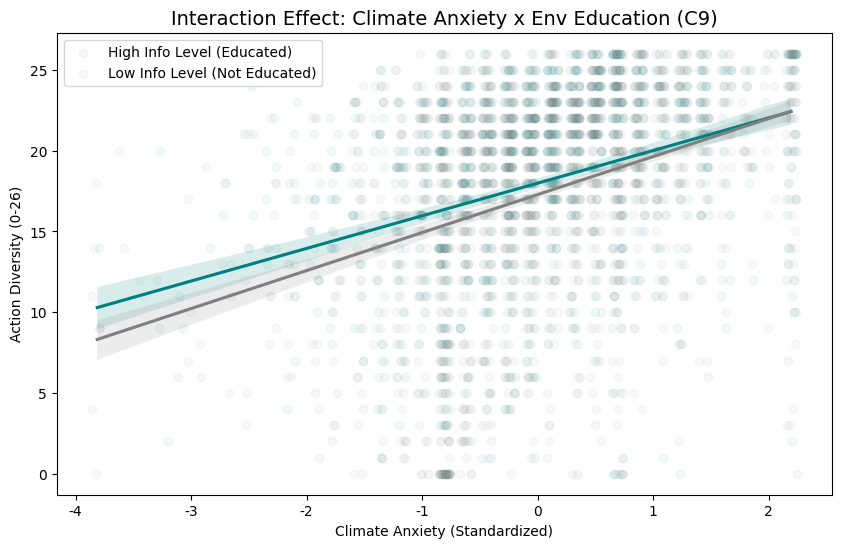

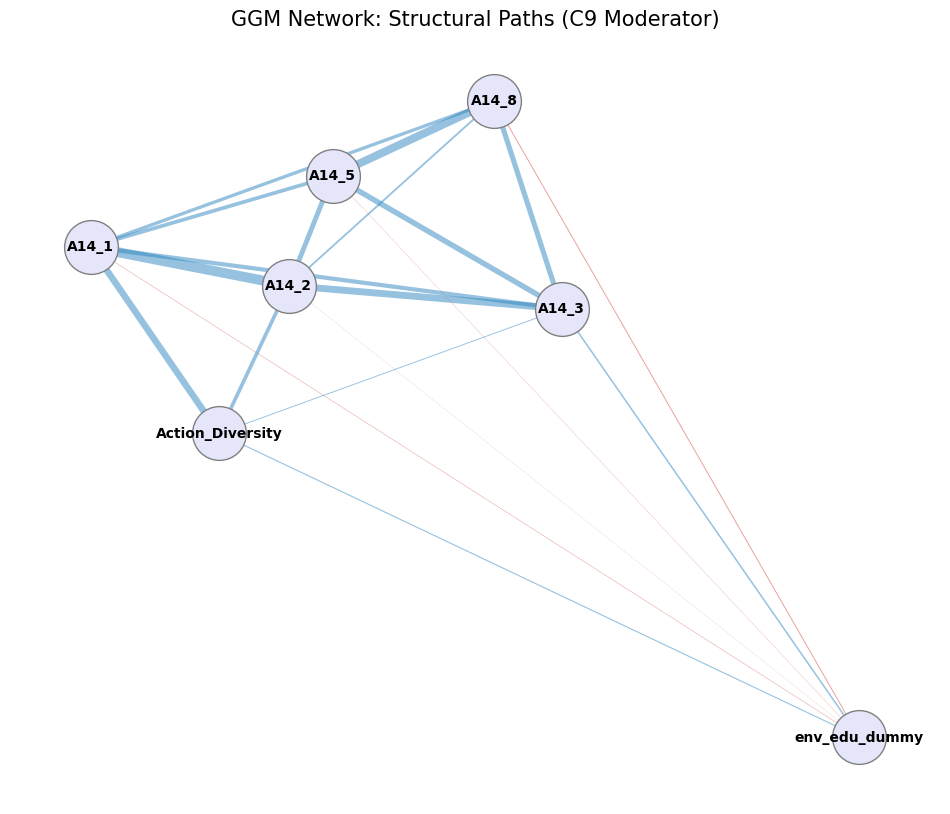

In [ ]:
b3_cols = [f'B3_{i}' for i in range(1, 13)]
b4_cols = [f'B4_{i}' for i in range(1, 15)]

for col in b3_cols: df[f'{col}_bin'] = np.where(df[col] >= 4, 1, 0)
for col in b4_cols: df[f'{col}_bin'] = np.where(df[col] == 1, 1, 0)
df['Action_Diversity'] = df[[f'{col}_bin' for col in (b3_cols + b4_cols)]].sum(axis=1)
df['Anxiety_Index'] = df[[f'A14_{i}' for i in range(1, 9)]].fillna(df[[f'A14_{i}' for i in range(1, 9)]].median()).mean(axis=1)

df['env_edu_dummy'] = np.where(df['C9'] == 1, 1, 0)

df['DM8_clean'] = df['DM8'].replace(9, np.nan).fillna(df['DM8'].median())

scaler = StandardScaler()
df['Anxiety_S'] = scaler.fit_transform(df[['Anxiety_Index']])
clean_df = df.dropna(subset=['Action_Diversity', 'Anxiety_S', 'env_edu_dummy', 'DM1', 'DM2', 'DM4', 'DM7', 'DM8_clean']).copy()
clean_df['Inter_Anx_Edu'] = clean_df['Anxiety_S'] * clean_df['env_edu_dummy']

formula = 'Action_Diversity ~ Anxiety_S + env_edu_dummy + Inter_Anx_Edu + C(DM1) + C(DM2) + C(DM4) + C(DM7) + C(DM8_clean)'
model = smf.ols(formula, data=clean_df).fit()

print(model.summary().tables[1])

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x='Anxiety_S', y='Action_Diversity', data=clean_df[clean_df['env_edu_dummy'] == 1], 
            label='High Info Level (Educated)', color='teal', scatter_kws={'alpha':0.05}, x_jitter=0.05)
sns.regplot(x='Anxiety_S', y='Action_Diversity', data=clean_df[clean_df['env_edu_dummy'] == 0], 
            label='Low Info Level (Not Educated)', color='gray', scatter_kws={'alpha':0.05}, x_jitter=0.05)
plt.title('Interaction Effect: Climate Anxiety x Env Education (C9)', fontsize=14)
plt.xlabel('Climate Anxiety (Standardized)')
plt.ylabel('Action Diversity (0-26)')
plt.legend()
plt.savefig('final_c9_interaction.png')

network_nodes = [f'A14_{i}' for i in [1, 2, 3, 5, 8]] + ['Action_Diversity', 'env_edu_dummy']
X_net = StandardScaler().fit_transform(clean_df[network_nodes])

glasso = GraphicalLassoCV(cv=5).fit(X_net)
precision = glasso.precision_
d = np.sqrt(np.diag(precision))
partial_corr = -precision / np.outer(d, d)
np.fill_diagonal(partial_corr, 0)

G = nx.from_numpy_array(partial_corr)
G = nx.relabel_nodes(G, {i: network_nodes[i] for i in range(len(network_nodes))})

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)
edges = G.edges(data=True)
edge_widths = [abs(d['weight']) * 20 for u, v, d in edges]
edge_colors = ['#2E86C1' if d['weight'] > 0 else '#CB4335' for u, v, d in edges]

nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lavender', edgecolors='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.5)

plt.title("GGM Network: Structural Paths (C9 Moderator)", fontsize=15)
plt.axis('off')
plt.savefig('final_c9_network.png')

print("\n[완료] 분석 결과와 그래프 2종이 저장되었습니다.")

Optimization terminated successfully.
         Current function value: 3.354261
         Iterations: 25
         Function evaluations: 28
         Gradient evaluations: 28
                     NegativeBinomial Regression Results                      
Dep. Variable:       Action_Diversity   No. Observations:                 3040
Model:               NegativeBinomial   Df Residuals:                     3021
Method:                           MLE   Df Model:                           18
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                 0.02556
Time:                        21:12:09   Log-Likelihood:                -10197.
converged:                       True   LL-Null:                       -10464.
Covariance Type:            nonrobust   LLR p-value:                4.825e-102
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept   

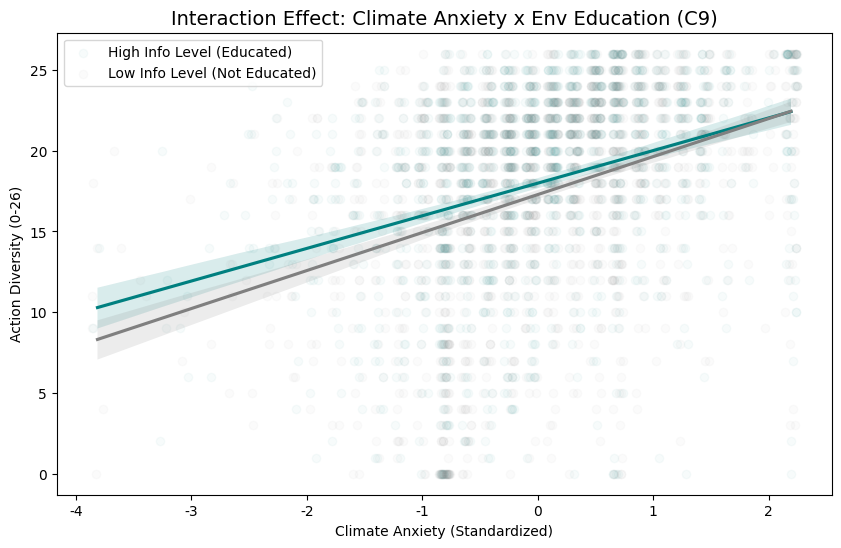

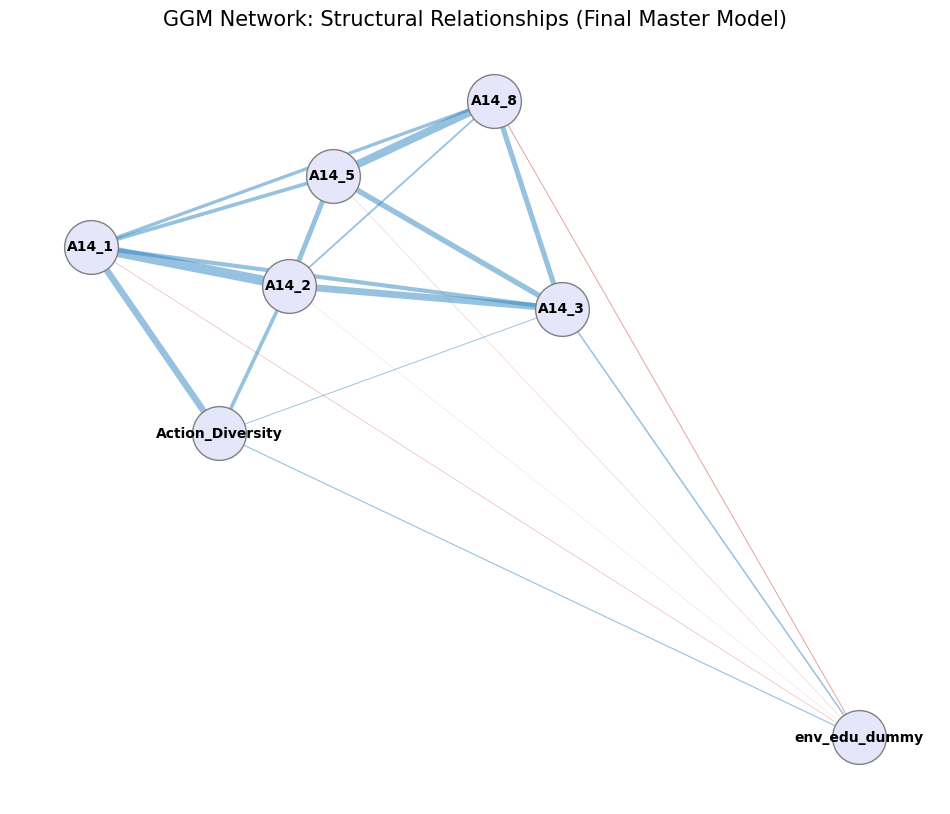

In [12]:
### Dependent variable
b3_cols = [f'B3_{i}' for i in range(1, 13)]
b4_cols = [f'B4_{i}' for i in range(1, 15)]

for col in b3_cols: df[f'{col}_bin'] = np.where(df[col] >= 4, 1, 0)
for col in b4_cols: df[f'{col}_bin'] = np.where(df[col] == 1, 1, 0)
df['Action_Diversity'] = df[[f'{col}_bin' for col in (b3_cols + b4_cols)]].sum(axis=1)

df['Anxiety_Index'] = df[[f'A14_{i}' for i in range(1, 9)]].fillna(df[[f'A14_{i}' for i in range(1, 9)]].median()).mean(axis=1)

### Moderator
df['env_edu_dummy'] = np.where(df['C9'] == 1, 1, 0)

trust_cols = [f'B6_{i}' for i in range(1, 8)]
X_trust = df[trust_cols].replace(9, np.nan).fillna(df[trust_cols].median())
scaler_w = StandardScaler()
W_scaled = scaler_w.fit_transform(X_trust)

pca_w = PCA(n_components=1)
df['Social_Trust'] = pca_w.fit_transform(W_scaled)
if df['Social_Trust'].corr(df['B6_1']) < 0:
    df['Social_Trust'] = -df['Social_Trust']

df['Social_Trust_C'] = df['Social_Trust'] - df['Social_Trust'].mean()

### Independent variables
scaler = StandardScaler()
df['Anxiety_S'] = scaler.fit_transform(df[['Anxiety_Index']])

### Table preparation
df['DM8_clean'] = df['DM8'].replace(9, np.nan).fillna(df['DM8'].median())
clean_df = df.dropna(subset=['Action_Diversity', 'Anxiety_S', 'env_edu_dummy', 'Social_Trust_C', 'DM1', 'DM2', 'DM4', 'DM7', 'DM8_clean']).copy()

formula = 'Action_Diversity ~ Anxiety_S * env_edu_dummy + C(DM1) + C(DM2) + C(DM4) + C(DM7) + C(DM8_clean)'
model_nb = smf.negativebinomial(formula, data=clean_df).fit()
print(model_nb.summary())

plt.figure(figsize=(10, 6))
sns.regplot(x='Anxiety_S', y='Action_Diversity', data=clean_df[clean_df['env_edu_dummy'] == 1], 
            label='High Info Level (Educated)', color='teal', scatter_kws={'alpha':0.03}, x_jitter=0.05)
sns.regplot(x='Anxiety_S', y='Action_Diversity', data=clean_df[clean_df['env_edu_dummy'] == 0], 
            label='Low Info Level (Not Educated)', color='gray', scatter_kws={'alpha':0.03}, x_jitter=0.05)
plt.title('Interaction Effect: Climate Anxiety x Env Education (C9)', fontsize=14)
plt.xlabel('Climate Anxiety (Standardized)')
plt.ylabel('Action Diversity (0-26)')
plt.legend()
plt.savefig('final_master_interaction.png')

network_nodes = [f'A14_{i}' for i in [1, 2, 3, 5, 8]] + ['Action_Diversity', 'env_edu_dummy']
X_net = StandardScaler().fit_transform(clean_df[network_nodes])

glasso = GraphicalLassoCV(cv=5).fit(X_net)
precision = glasso.precision_
d = np.sqrt(np.diag(precision))
partial_corr = -precision / np.outer(d, d)
np.fill_diagonal(partial_corr, 0)

G = nx.from_numpy_array(partial_corr)
G = nx.relabel_nodes(G, {i: network_nodes[i] for i in range(len(network_nodes))})

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)
edges = G.edges(data=True)
edge_widths = [abs(d['weight']) * 20 for u, v, d in edges]
edge_colors = ['#2E86C1' if d['weight'] > 0 else '#CB4335' for u, v, d in edges]

nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lavender', edgecolors='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.5)

plt.title("GGM Network: Structural Relationships (Final Master Model)", fontsize=15)
plt.axis('off')
plt.savefig('final_master_network.png')

=== 다중공선성(VIF) 체크 결과 ===
                           Feature        VIF
0                        Intercept  17.606771
10                     C(DM7)[T.7]   2.613401
7                      C(DM7)[T.3]   2.196426
8                      C(DM7)[T.4]   2.049942
6                      C(DM7)[T.2]   1.999193
4                      C(DM2)[T.5]   1.926850
5                      C(DM2)[T.6]   1.909132
9                      C(DM7)[T.5]   1.870779
3                      C(DM2)[T.4]   1.811953
2                      C(DM2)[T.3]   1.707313
12              C(ideology)[T.3.0]   1.487427
11              C(ideology)[T.2.0]   1.456219
14                  Social_Trust_C   1.183525
15  Anxiety_Index_C:Social_Trust_C   1.116420
13                 Anxiety_Index_C   1.088391
1                      C(DM1)[T.2]   1.042386
=== 연속형 지수 기반 조절효과 분석 결과 ===

[종속변수: Y0]
                            OLS Regression Results                            
Dep. Variable:                     Y0   R-squared:                       

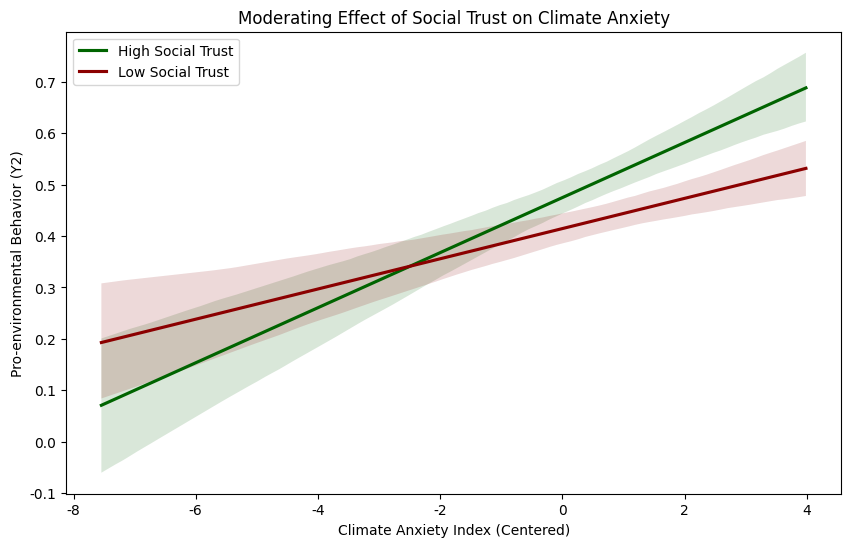

In [76]:
### Dependent variable
b4_cols = [f'B4_{i}' for i in range(1, 15)]
for col in b4_cols: df[col] = np.where(df[col] == 1, 1, 0)
df['Y0'] = df[['B4_1', 'B4_2', 'B4_3', 'B4_4', 'B4_5', 'B4_6', 'B4_7', 'B4_10', 'B4_13','B4_11', 'B4_12', 'B4_14']].mean(axis=1)
df['Y1_Conservation'] = df[['B4_1', 'B4_2', 'B4_3', 'B4_4', 'B4_5']].mean(axis=1)
df['Y2_Consumption'] = df[['B4_6', 'B4_7', 'B4_10', 'B4_13']].mean(axis=1)
df['Y3_Recycling'] = df[['B4_11', 'B4_12', 'B4_14']].mean(axis=1)

### Independent variable
emotion_cols = [f'A14_{i}' for i in range(1, 9)]
X_emotions = df[emotion_cols].fillna(df[emotion_cols].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_emotions)
pca = PCA(n_components = 1) 
df['Anxiety_Index'] = pca.fit_transform(X_scaled)
df['Anxiety_Index_C'] = df['Anxiety_Index'] - df['Anxiety_Index'].mean()

### Moderator
# trust_cols = [f'B6_{i}' for i in range(1, 8)]
# X_trust = df[trust_cols].replace(9, np.nan).fillna(df[trust_cols].median())
# df['Social_Trust'] = X_trust.mean(axis=1)
# df['Social_Trust_C'] = df['Social_Trust'] - df['Social_Trust'].mean()

trust_cols = [f'B6_{i}' for i in range(1, 8)]
X_trust = df[trust_cols].replace(9, np.nan).fillna(df[trust_cols].median())
scaler_w = StandardScaler()
W_scaled = scaler_w.fit_transform(X_trust)

pca_w = PCA(n_components=1)
df['Social_Trust'] = pca_w.fit_transform(W_scaled)
if df['Social_Trust'].corr(df['B6_1']) < 0:
    df['Social_Trust'] = -df['Social_Trust']

df['Social_Trust_C'] = df['Social_Trust'] - df['Social_Trust'].mean()

#
df['edu_dummy'] = df['C9'].map({1: 1, 2: 0})
df['ideology'] = df['DM8'].replace(9, np.nan)
clean_df = df.dropna(subset=['Anxiety_Index_C', 'Social_Trust_C', 'Y0', 'DM1', 'DM2', 'DM8'])

### Regression
formula_vif = 'Anxiety_Index_C * Social_Trust_C + C(DM1) + C(DM2) + C(DM7) + C(ideology)'

clean_df_vif = df.dropna(subset=['Anxiety_Index_C', 'Social_Trust_C', 'edu_dummy', 'DM1', 'DM2', 'DM7', 'DM8'])
y, X = patsy.dmatrices(f'Y2_Consumption ~ {formula_vif}', clean_df_vif, return_type='dataframe')

# 2. VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("=== 다중공선성(VIF) 체크 결과 ===")
print(vif_data.sort_values(by="VIF", ascending=False))

y_targets = ['Y0','Y1_Conservation', 'Y2_Consumption', 'Y3_Recycling']
formula = ' ~ Anxiety_Index_C * edu_dummy + C(DM1) + C(DM2) + C(DM7) + C(ideology)'

print("=== 연속형 지수 기반 조절효과 분석 결과 ===")
for y in y_targets:
    model = smf.ols(y + formula, data=clean_df).fit()
    print(f"\n[종속변수: {y}]")
    print(model.summary())
    print(model.summary().tables[1])

std_trust = clean_df['Social_Trust_C'].std()
clean_df['Trust_Group'] = np.where(clean_df['Social_Trust_C'] > std_trust, 'High Trust (+1SD)', 
                         np.where(clean_df['Social_Trust_C'] < -std_trust, 'Low Trust (-1SD)', 'Medium'))

plt.figure(figsize=(10, 6))
sns.regplot(x='Anxiety_Index_C', y='Y2_Consumption', data=clean_df[clean_df['Trust_Group']=='High Trust (+1SD)'], 
            scatter=False, label='High Social Trust', color='darkgreen')
sns.regplot(x='Anxiety_Index_C', y='Y2_Consumption', data=clean_df[clean_df['Trust_Group']=='Low Trust (-1SD)'], 
            scatter=False, label='Low Social Trust', color='darkred')

plt.title("Moderating Effect of Social Trust on Climate Anxiety")
plt.xlabel("Climate Anxiety Index (Centered)")
plt.ylabel("Pro-environmental Behavior (Y2)")
plt.legend()
plt.show()

# plt.figure(figsize=(10, 6))
# sns.regplot(x='Anxiety_Index_C', y='Y1_Conservation', data=clean_df[clean_df['edu_dummy']==1], 
#             scatter=False, label='Education: Yes', color='orange')
# sns.regplot(x='Anxiety_Index_C', y='Y1_Conservation', data=clean_df[clean_df['edu_dummy']==0], 
#             scatter=False, label='Education: No', color='blue')
# plt.title("Moderating Effect of Education on Continuous Anxiety Index")
# plt.xlabel("Climate Anxiety Index (Continuous, Centered)")
# plt.ylabel("Environmental Consumption Score")
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.regplot(x='Anxiety_Index_C', y='Y2_Consumption', data=clean_df[clean_df['edu_dummy']==1], 
#             scatter=False, label='Education: Yes', color='orange')
# sns.regplot(x='Anxiety_Index_C', y='Y2_Consumption', data=clean_df[clean_df['edu_dummy']==0], 
#             scatter=False, label='Education: No', color='blue')
# plt.title("Moderating Effect of Education on Continuous Anxiety Index")
# plt.xlabel("Climate Anxiety Index (Continuous, Centered)")
# plt.ylabel("Environmental Consumption Score")
# plt.legend()
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.regplot(x='Anxiety_Index_C', y='Y3_Recycling', data=clean_df[clean_df['edu_dummy']==1], 
#             scatter=False, label='Education: Yes', color='orange')
# sns.regplot(x='Anxiety_Index_C', y='Y3_Recycling', data=clean_df[clean_df['edu_dummy']==0], 
#             scatter=False, label='Education: No', color='blue')
# plt.title("Moderating Effect of Education on Continuous Anxiety Index")
# plt.xlabel("Climate Anxiety Index (Continuous, Centered)")
# plt.ylabel("Environmental Consumption Score")
# plt.legend()
# plt.show()


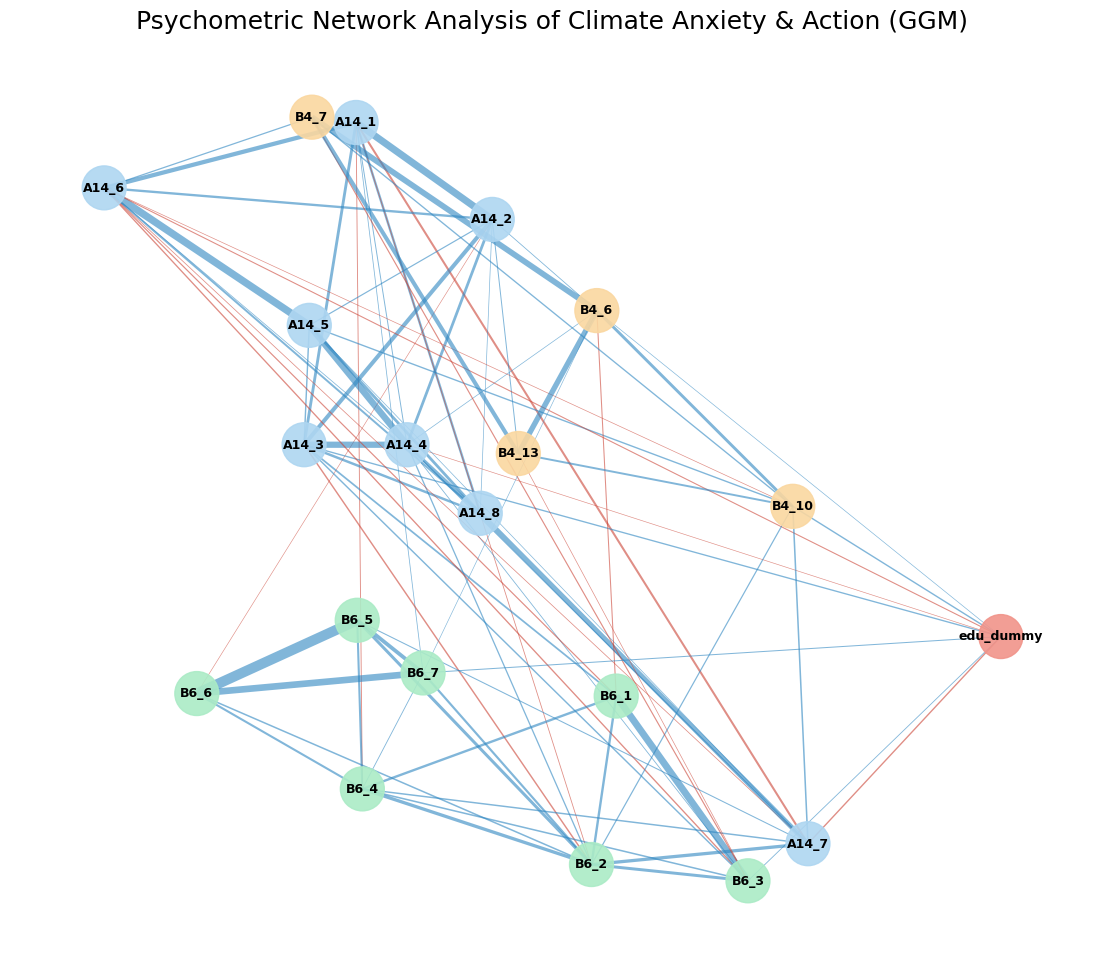

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV

# 1. 분석 대상 노드(문항) 선정
# 개별 문항 수준에서 분석해야 네트워크의 구조적 특징이 명확히 드러납니다.
nodes = [f'A14_{i}' for i in range(1, 9)] + [f'B6_{i}' for i in range(1, 8)] + \
        ['B4_6', 'B4_7', 'B4_10', 'B4_13', 'edu_dummy']

# 2. 데이터 표준화
# GGM은 변수의 스케일에 민감하므로 표준화가 필수적입니다.
X = clean_df[nodes].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Graphical Lasso를 통한 희소 정밀 행렬(Precision Matrix) 추정
# Lasso 규제를 통해 위양성 연결을 제거하고 핵심적인 관계만 남깁니다.
model = GraphicalLassoCV(cv=5)
model.fit(X_scaled)

# 정밀 행렬로부터 편상관계수(Partial Correlation) 행렬 계산
precision = model.precision_
d = np.sqrt(np.diag(precision))
partial_corr = -precision / np.outer(d, d)
np.fill_diagonal(partial_corr, 0)

# 4. 네트워크 시각화 (NetworkX)
G = nx.from_numpy_array(partial_corr)
mapping = {i: nodes[i] for i in range(len(nodes))}
G = nx.relabel_nodes(G, mapping)

# 시각화 설정
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, k=0.6, seed=42)

# 노드 그룹별 색상 설정
node_colors = []
for node in G.nodes():
    if node.startswith('A14'): node_colors.append('#AED6F1') # 기후 불안 (하늘색)
    elif node.startswith('B6'): node_colors.append('#ABEBC6') # 사회적 신뢰 (연두색)
    elif node.startswith('B4'): node_colors.append('#FAD7A0') # 환경 행동 (주황색)
    else: node_colors.append('#F1948A') # 교육 수준 (분홍색)

# 엣지 필터링 (가중치가 낮은 연결은 시각화에서 제외)
edges = [(u, v) for u, v, d in G.edges(data=True) if abs(d['weight']) > 0.03]
weights = [G[u][v]['weight'] * 15 for u, v in edges]
edge_colors = ['#2E86C1' if G[u][v]['weight'] > 0 else '#CB4335' for u, v in edges]

# 드로잉
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color=edge_colors, alpha=0.6)

plt.title("Psychometric Network Analysis of Climate Anxiety & Action (GGM)", fontsize=18)
plt.axis('off')
plt.show()

기준 집단(Reference Group): Cluster 1

 [결과] 기후 감정 군집 x 사회적 자본 조절효과 분석 

▶ 종속변수: Y1_Conservation
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                            0.3329      0.032     10.468      0.000       0.271       0.395
C(Anxiety_Cluster, Treatment(reference=1))[T.0]                      0.1402      0.022      6.455      0.000       0.098       0.183
C(Anxiety_Cluster, Treatment(reference=1))[T.2]                      0.0561      0.020      2.857      0.004       0.018       0.095
C(Anxiety_Cluster, Treatment(reference=1))[T.3]                      0.1997      0.022      8.960      0.000       0.156       0.243
Social_Capital_C                                                    -0.0397      0.032     -1.232      0.218 

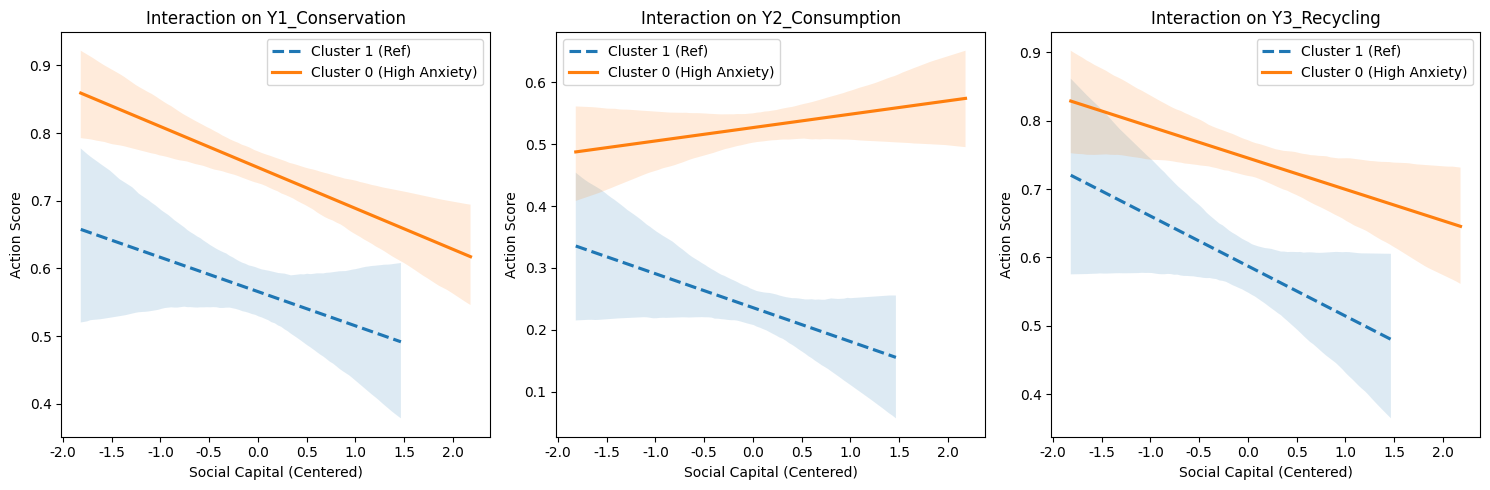

In [46]:
plt.rcdefaults()
plt.rcParams['axes.unicode_minus'] = False

# -----------------------------------------------------------------
# 2. 변수 생성 (DVs, IVs, MV, Controls)
# -----------------------------------------------------------------

# [Y] 종속변수: 환경 실천 행동 (B4 문항)
b4_cols = [f'B4_{i}' for i in range(1, 15)]
for col in b4_cols: df[col] = np.where(df[col] == 1, 1, 0)

df['Y1_Conservation'] = df[['B4_1', 'B4_2', 'B4_3', 'B4_4', 'B4_5']].mean(axis=1)
df['Y2_Consumption'] = df[['B4_6', 'B4_7', 'B4_10', 'B4_13']].mean(axis=1)
df['Y3_Recycling'] = df[['B4_11', 'B4_12', 'B4_14']].mean(axis=1)

# [X] 독립변수 군집화: 기후 감정 (A14 문항)
emotion_cols = [f'A14_{i}' for i in range(1, 9)]
X_emotions = df[emotion_cols].fillna(df[emotion_cols].median())
X_scaled = StandardScaler().fit_transform(X_emotions)

# K-means 클러스터링 (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100).fit(X_scaled)
df['Anxiety_Cluster'] = kmeans.labels_

# 기준 집단(Reference) 자동 설정: 감정 점수 합계가 가장 낮은 군집
cluster_means = df.groupby('Anxiety_Cluster')[emotion_cols].mean().mean(axis=1)
ref_cluster = cluster_means.idxmin()
print(f"기준 집단(Reference Group): Cluster {ref_cluster}")

# [W] 조절변수: 사회적 자본 (B6_1~B6_7 신뢰도)
trust_cols = [f'B6_{i}' for i in range(1, 8)]
df['Social_Capital'] = df[trust_cols].replace(9, np.nan).fillna(df[trust_cols].median()).mean(axis=1)
# 평균 중심화 (Mean Centering) - 상호작용 해석의 핵심
df['Social_Capital_C'] = df['Social_Capital'] - df['Social_Capital'].mean()

# [Controls] 통제변수 (교수님 요청: 연속형 및 더미)
df['gender_dummy'] = df['DM1'].map({1: 0, 2: 1}) # 0:남, 1:여
df['Age_numeric'] = df['DM2'].astype(float)
df['Income_numeric'] = df['DM7'].astype(float)
df['Ideology_numeric'] = df['DM8'].replace(9, np.nan).fillna(df['DM8'].median()).astype(float)
df['edu_dummy'] = df['C9'].map({1: 1, 2: 0}) # 1:교육유, 0:무

# 분석용 클린 데이터
clean_df = df.dropna(subset=['Anxiety_Cluster', 'Social_Capital_C', 'Y2_Consumption', 'Ideology_numeric']).copy()

# -----------------------------------------------------------------
# 3. 조절효과 회귀 분석 (Interaction Analysis)
# -----------------------------------------------------------------
y_targets = ['Y1_Conservation', 'Y2_Consumption', 'Y3_Recycling']
# formula = f' ~ C(Anxiety_Cluster, Treatment(reference={ref_cluster})) * Social_Capital_C + gender_dummy + Age_numeric + Income_numeric + Ideology_numeric + edu_dummy'
formula = f' ~ C(Anxiety_Cluster, Treatment(reference={ref_cluster})) * Social_Capital_C + DM1 + DM2 + DM7 + DM8 + edu_dummy'

print("\n" + "="*80)
print(" [결과] 기후 감정 군집 x 사회적 자본 조절효과 분석 ")
print("="*80)

for y in y_targets:
    model = smf.ols(y + formula, data=clean_df).fit()
    print(f"\n▶ 종속변수: {y}")
    # 상호작용항(Cluster:Social_Capital_C)의 유의성 확인
    print(model.summary().tables[1])

# -----------------------------------------------------------------
# 4. 시각화: 단순 기울기 분석 (Simple Slope Plot)
# -----------------------------------------------------------------
plt.figure(figsize=(15, 5))
for i, y in enumerate(y_targets):
    plt.subplot(1, 3, i+1)
    # 각 군집별로 사회적 자본에 따른 행동 변화의 기울기 출력
    sns.regplot(x='Social_Capital_C', y=y, data=clean_df[clean_df['Anxiety_Cluster']==ref_cluster], 
                scatter=False, label=f'Cluster {ref_cluster} (Ref)', line_kws={'ls':'--'})
    
    # 다른 주요 군집 하나 예시 (감정이 가장 높은 군집)
    top_cluster = cluster_means.idxmax()
    sns.regplot(x='Social_Capital_C', y=y, data=clean_df[clean_df['Anxiety_Cluster']==top_cluster], 
                scatter=False, label=f'Cluster {top_cluster} (High Anxiety)')
    
    plt.title(f'Interaction on {y}')
    plt.xlabel('Social Capital (Centered)')
    plt.ylabel('Action Score')
    plt.legend()

plt.tight_layout()
plt.show()

# SEM

In [52]:
from semopy import Model, Optimizer
from semopy.inspector import inspect

# 1. 모델 정의 (측정 모델 + 구조 모델)
# 감정(Anxiety), 사회적 자본(Trust), 환경 행동(Action)을 잠재 변수로 정의
model_spec = """
    # 측정 모델 (Measurement Model)
    Anxiety =~ A14_1 + A14_2 + A14_3 + A14_4 + A14_5 + A14_6 + A14_7 + A14_8
    Trust =~ B6_1 + B6_2 + B6_3 + B6_4 + B6_5 + B6_6 + B6_7
    Action =~ B4_6 + B4_7 + B4_10 + B4_13
    
    # 구조 모델 (Structural Model)
    Action ~ Anxiety + Trust
    
    # 공분산 및 잔차 설정
    Anxiety ~~ Trust
"""

# 2. 모델 실행
m = Model(model_spec)
m.fit(clean_df) # 결측치가 제거된 데이터프레임 사용

# 3. 결과 확인 (경로 계수 및 유의성)
results = inspect(m)
print(results[results['op'] == '~']) # 구조 경로만 출력

# 4. 모델 적합도 확인 (CFI, TLI, RMSEA 등)
from semopy import calc_stats
stats = calc_stats(m)
print(stats.T)

      lval op     rval  Estimate  Std. Err    z-value  p-value
0   Action  ~  Anxiety  0.227160  0.014482  15.686122      0.0
1   Action  ~    Trust  0.179513  0.049407   3.633333  0.00028
2    A14_1  ~  Anxiety  1.000000         -          -        -
3    A14_2  ~  Anxiety  1.134310  0.030753  36.884096      0.0
4    A14_3  ~  Anxiety  1.134277  0.031648  35.839924      0.0
5    A14_4  ~  Anxiety  1.342376  0.034387  39.037741      0.0
6    A14_5  ~  Anxiety  1.280031  0.033145  38.619562      0.0
7    A14_6  ~  Anxiety  1.184547  0.032974  35.923847      0.0
8    A14_7  ~  Anxiety  0.273229  0.037772    7.23364      0.0
9    A14_8  ~  Anxiety  1.019833  0.031118   32.77268      0.0
10    B6_1  ~    Trust  1.000000         -          -        -
11    B6_2  ~    Trust  2.795987  0.331926   8.423517      0.0
12    B6_3  ~    Trust  0.961272  0.157009   6.122415      0.0
13    B6_4  ~    Trust  2.577756  0.310654   8.297846      0.0
14    B6_5  ~    Trust  4.465497  0.514173    8.68482  

In [68]:
# [DV] 친환경 소비 행동 (1: 실천, 0: 미실천)
action_cols = ['B4_6', 'B4_7', 'B4_10', 'B4_13']
for col in action_cols:
    df[col] = np.where(df[col] == 1, 1, 0)

# [Control Variables]
df['gender_dummy'] = df['DM1'].map({1: 0, 2: 1})
df['Age_numeric'] = df['DM2'].astype(float)
df['Income_numeric'] = df['DM7'].astype(float)
df['Ideology_numeric'] = df['DM8'].replace(9, np.nan).fillna(df['DM8'].median()).astype(float)
df['edu_dummy'] = df['C9'].map({1: 1, 2: 0})

# -----------------------------------------------------------------
# 2. 군집화 및 데이터 정제
# -----------------------------------------------------------------
emotion_cols = [f'A14_{i}' for i in range(1, 9)]
X_emotions = df[emotion_cols].fillna(df[emotion_cols].median())
X_scaled = StandardScaler().fit_transform(X_emotions)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100).fit(X_scaled)
df['Anxiety_Cluster'] = kmeans.labels_

trust_cols = [f'B6_{i}' for i in range(1, 8)]
all_vars = emotion_cols + trust_cols + action_cols + \
           ['gender_dummy', 'Age_numeric', 'Income_numeric', 'Ideology_numeric', 'edu_dummy', 'Anxiety_Cluster']
clean_df = df.dropna(subset=all_vars).copy()

# -----------------------------------------------------------------
# 3. SEM 모델 정의 (측정 + 구조 + 통제)
# -----------------------------------------------------------------
model_spec = """
    # 측정 모델 (Measurement Model)
    Anxiety =~ A14_1 + A14_2 + A14_3 + A14_4 + A14_5 + A14_6 + A14_7 + A14_8
    SocialCap =~ B6_1 + B6_2 + B6_3 + B6_4 + B6_5 + B6_6 + B6_7
    Action =~ B4_6 + B4_7 + B4_10 + B4_13
    
    # 구조 모델 (Structural Model)
    Action ~ Anxiety + SocialCap + gender_dummy + Age_numeric + Income_numeric + Ideology_numeric + edu_dummy
    
    # 공분산
    Anxiety ~~ SocialCap
"""

# -----------------------------------------------------------------
# 4. 군집별 분석 및 표준화 결과 출력
# -----------------------------------------------------------------
clusters = sorted(clean_df['Anxiety_Cluster'].unique())

for cid in clusters:
    group_data = clean_df[clean_df['Anxiety_Cluster'] == cid]
    if len(group_data) < 100: continue
    
    print(f"\n" + "="*20 + f" Cluster {cid} 분석 시도 " + "="*20)
    
    m = Model(model_spec)
    
    # [Tip] 수렴 실패 시 'em' 옵션이나 다른 optimizer를 시도할 수 있습니다.
    # fit 결과(객체)를 명확히 확인합니다.
    result = m.fit(group_data)
    
    # 모델이 수렴(Convergence)했는지 확인
    if result.success:
        print(f"✓ Cluster {cid}: 모델 수렴 성공")
        
        # [A] 표준화 결과 추출
        ins_std = inspect(m, mode='std')
        if ins_std is not None:
            print(f"\n[가설 검증 결과 (Beta)]")
            struct_paths = ins_std[ins_std['op'] == '~'][['lval', 'rval', 'Est. Std', 'p-value']]
            print(struct_paths)
        
        # [B] 적합도 계산 (에러 방어 로직)
        stats = calc_stats(m)
        if stats is not None:
            available_fit = [idx for idx in ['CFI', 'TLI', 'RMSEA'] if idx in stats.columns]
            print(f"\n[모델 적합도]\n{stats[available_fit].T}")
        else:
            print("⚠ 적합도 계산 실패 (Model Fit object is None)")
            
    else:
        print(f"✗ Cluster {cid}: 모델 수렴 실패 (Optimization Failed)")
        print(f"사유: {result.message}") # 에러 원인 출력


==================== Cluster 0 분석 시도 ====================
✓ Cluster 0: 모델 수렴 성공

[모델 적합도]
          Value
CFI    0.832329
TLI    0.814506
RMSEA  0.060176

==================== Cluster 1 분석 시도 ====================
✓ Cluster 1: 모델 수렴 성공

[모델 적합도]
          Value
CFI    0.603655
TLI    0.561524
RMSEA  0.073172

==================== Cluster 2 분석 시도 ====================
✓ Cluster 2: 모델 수렴 성공

[모델 적합도]
          Value
CFI    0.637240
TLI    0.598679
RMSEA  0.063777

==================== Cluster 3 분석 시도 ====================
✓ Cluster 3: 모델 수렴 성공

[모델 적합도]
          Value
CFI    0.667969
TLI    0.632675
RMSEA  0.066445


### LCA check

최적의 K를 찾는 중...
BIC 기준 최적의 계층 수: K=6

 종속변수: Y1_Conservation (모델 설명력 R2: 0.0888)
                                                        Coef   P-value
C(LCA_Class, Treatment(reference=0))[T.1]:edu_d...  0.057530  0.408103
C(LCA_Class, Treatment(reference=0))[T.2]:edu_d...  0.034988  0.627372
C(LCA_Class, Treatment(reference=0))[T.3]:edu_d...  0.136190  0.467422
C(LCA_Class, Treatment(reference=0))[T.4]:edu_d...  0.021029  0.763268
C(LCA_Class, Treatment(reference=0))[T.5]:edu_d...  0.035453  0.597355

 종속변수: Y2_Consumption (모델 설명력 R2: 0.0829)
                                                        Coef   P-value
C(LCA_Class, Treatment(reference=0))[T.1]:edu_d...  0.184935  0.009178
C(LCA_Class, Treatment(reference=0))[T.2]:edu_d...  0.139644  0.057615
C(LCA_Class, Treatment(reference=0))[T.3]:edu_d...  0.200024  0.295486
C(LCA_Class, Treatment(reference=0))[T.4]:edu_d...  0.166572  0.019409
C(LCA_Class, Treatment(reference=0))[T.5]:edu_d...  0.142952  0.036885

 종속변수: Y3_Recycling (모델 

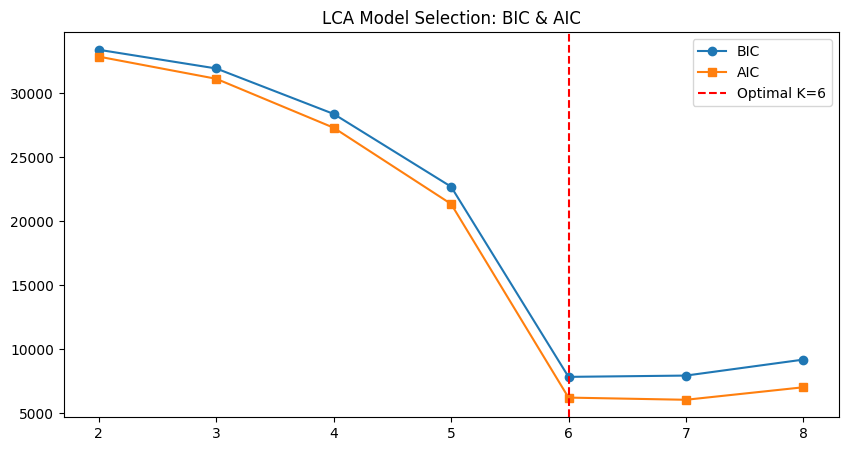

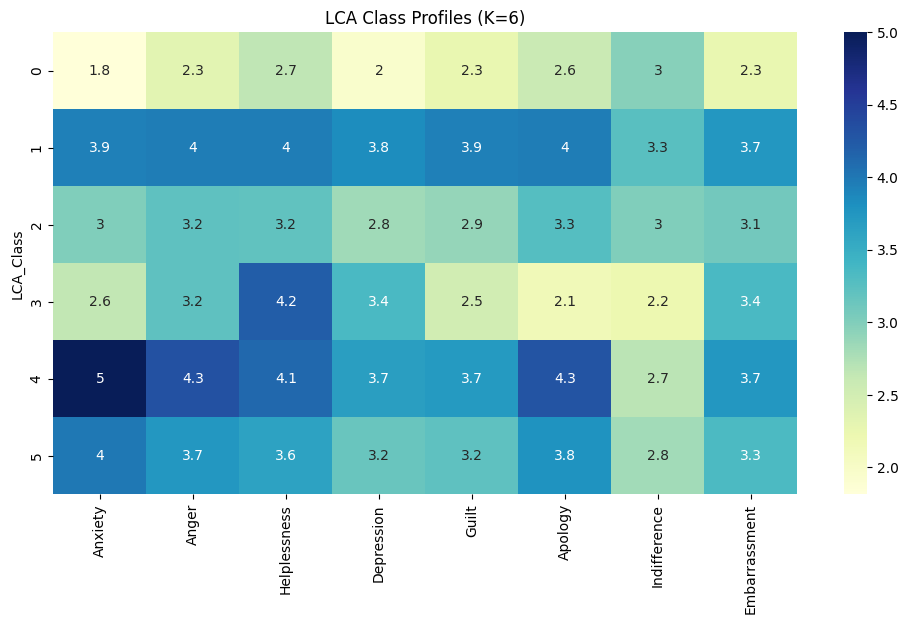

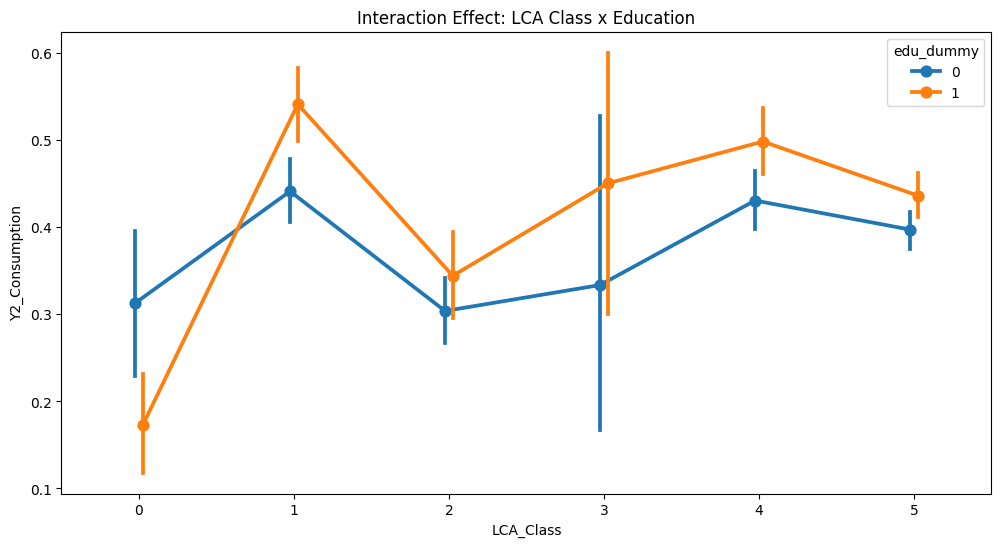

                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                               0.5225      0.056      9.304      0.000       0.412       0.633
C(LCA_Class, Treatment(reference=0))[T.1]               0.0787      0.054      1.467      0.143      -0.027       0.184
C(LCA_Class, Treatment(reference=0))[T.2]              -0.0101      0.055     -0.183      0.854      -0.118       0.098
C(LCA_Class, Treatment(reference=0))[T.3]              -0.0561      0.127     -0.440      0.660      -0.306       0.194
C(LCA_Class, Treatment(reference=0))[T.4]               0.1755      0.054      3.253      0.001       0.070       0.281
C(LCA_Class, Treatment(reference=0))[T.5]               0.1273      0.052      2.436      0.015       0.025       0.230
C(DM1)[T.2]                             

In [ ]:
b4_cols = [f'B4_{i}' for i in range(1, 15)]
for col in b4_cols:
    df[col] = np.where(df[col] == 1, 1, 0)

df['Y1_Conservation'] = df[['B4_1', 'B4_2', 'B4_3', 'B4_4', 'B4_5']].mean(axis=1)
df['Y2_Consumption'] = df[['B4_6', 'B4_7', 'B4_10', 'B4_13']].mean(axis=1)
df['Y3_Recycling'] = df[['B4_11', 'B4_12', 'B4_14']].mean(axis=1)

emotion_cols = [f'A14_{i}' for i in range(1, 9)]
emotion_labels = ['Anxiety', 'Anger', 'Helplessness', 'Depression', 'Guilt', 'Apology', 'Indifference', 'Embarrassment']
X_emotions = df[emotion_cols].fillna(df[emotion_cols].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_emotions)

k_range = range(2, 9)
bics, aics = [], []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

# BIC가 최소가 되는 K를 최적으로 선정
optimal_k = k_range[np.argmin(bics)]
print(f"BIC 기준 최적의 계층 수: K={optimal_k}")

gmm_final = GaussianMixture(n_components=optimal_k, random_state=42, n_init=10)
df['LCA_Class'] = gmm_final.fit_predict(X_scaled)

### Regression
df['edu_dummy'] = df['C9'].map({1: 1, 2: 0})
df['ideology'] = df['DM8'].replace(9, np.nan)
clean_df = df.dropna(subset=['LCA_Class', 'edu_dummy', 'Y2_Consumption', 'DM1', 'DM2', 'DM7', 'DM8']).copy()

class_profiles = df.groupby('LCA_Class')[emotion_cols].mean()
ref_class = class_profiles.mean(axis=1).idxmin()

y_list = ['Y1_Conservation', 'Y2_Consumption', 'Y3_Recycling']
interaction_results = {}
for y in y_list:
    # Formula: $Y \sim C(Class) \times Education + Controls$
    formula = f'{y} ~ C(LCA_Class, Treatment(reference=0)) * edu_dummy + C(DM1) + C(DM2) + C(DM7) + C(ideology)'
    model = smf.ols(formula, data=clean_df).fit()
    
    interaction_results[y] = model
    
    print(f"\n" + "="*60)
    print(f" 종속변수: {y} (모델 설명력 R2: {model.rsquared:.4f})")
    print("="*60)

    summary_params = model.params[model.params.index.str.contains(':')]
    summary_pvals = model.pvalues[model.pvalues.index.str.contains(':')]
    
    result_df = pd.DataFrame({'Coef': summary_params, 'P-value': summary_pvals})
    print(result_df)

### Visualization
plt.figure(figsize=(10, 5))
plt.plot(k_range, bics, label='BIC', marker='o')
plt.plot(k_range, aics, label='AIC', marker='s')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title("LCA Model Selection: BIC & AIC")
plt.legend()
plt.show()

class_profiles.columns = emotion_labels
plt.figure(figsize=(12, 6))
sns.heatmap(class_profiles, annot=True, cmap='YlGnBu')
plt.title(f"LCA Class Profiles (K={optimal_k})")
plt.show()

plt.figure(figsize=(12, 6))
sns.pointplot(x='LCA_Class', y='Y2_Consumption', hue='edu_dummy', data=clean_df, dodge=True)
plt.title("Interaction Effect: LCA Class x Education")
plt.show()

print(model.summary().tables[1])

=== [모델 1] 역 U자형 검증 결과 ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.8930      0.203     14.227      0.000       2.494       3.292
C(DM1)[T.2]           -0.0076      0.040     -0.190      0.849      -0.086       0.071
C(DM2)[T.3]           -0.2073      0.068     -3.037      0.002      -0.341      -0.073
C(DM2)[T.4]           -0.4679      0.067     -6.971      0.000      -0.599      -0.336
C(DM2)[T.5]           -0.4281      0.067     -6.432      0.000      -0.559      -0.298
C(DM2)[T.6]           -0.5133      0.069     -7.444      0.000      -0.649      -0.378
C(DM3)[T.2]           -0.0753      0.057     -1.313      0.189      -0.188       0.037
C(DM3)[T.3]           -0.1552      0.075     -2.062      0.039      -0.303      -0.008
C(DM3)[T.4]           -0.0776      0.080     -0.968      0.333      -0.235       0.080
C(DM3)[T.5]     

<Figure size 1000x600 with 0 Axes>

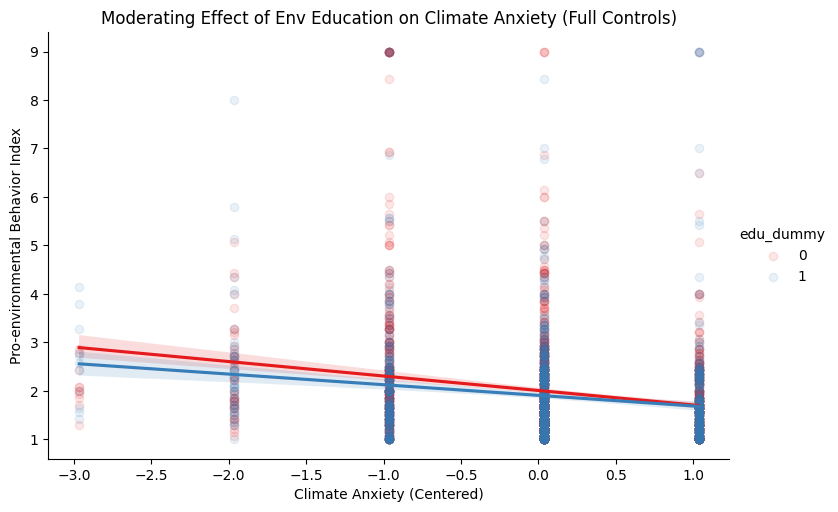

In [ ]:
behavior_cols = [f'B4_{i}' for i in range(1, 15)]
df['behavior_idx'] = df[behavior_cols].mean(axis=1)

df['Y1_Conservation'] = df[['B4_1', 'B4_2', 'B4_3', 'B4_4', 'B4_5']].mean(axis=1)
df['Y2_Consumption'] = df[['B4_6', 'B4_7', 'B4_10', 'B4_13']].mean(axis=1)
df['Y3_Recycling'] = df[['B4_11', 'B4_12', 'B4_14']].mean(axis=1)

df['anxiety_c'] = df['A14_1'] - df['A14_1'].mean()
df['anxiety_sq'] = df['anxiety_c'] ** 2

df['edu_dummy'] = df['C9'].map({1: 1, 2: 0})

df['ideology'] = df['DM8'].replace(9, np.nan)

df['gen_mz'] = np.where(df['DM2'] <= 3, 'MZ', 'Older')


analysis_cols = ['behavior_idx', 'anxiety_c', 'anxiety_sq', 'edu_dummy', 
                 'DM1', 'DM2', 'DM3', 'DM4', 'DM7', 'ideology', 'gen_mz']
clean_df = df[analysis_cols].dropna()

# --- 모델 1: 가설 1 (역 U자형 검증) ---
formula1 = 'behavior_idx ~ anxiety_c + anxiety_sq + C(DM1) + C(DM2) + C(DM3) + C(DM4) + C(DM7) + C(ideology)'
model1 = smf.ols(formula1, data=clean_df).fit()

# --- 모델 2: 가설 2 (교육의 조절효과 검증) ---
formula2 = 'behavior_idx ~ anxiety_c * edu_dummy + C(DM1) + C(DM2) + C(DM3) + C(DM4) + C(DM7) + C(ideology)'
model2 = smf.ols(formula2, data=clean_df).fit()

# --- 모델 3: 가설 3 (세대별 집단 분석) ---
model3_mz = smf.ols(formula2, data=clean_df[clean_df['gen_mz'] == 'MZ']).fit()
model3_older = smf.ols(formula2, data=clean_df[clean_df['gen_mz'] == 'Older']).fit()

print("=== [모델 1] 역 U자형 검증 결과 ===")
print(model1.summary().tables[1])

print("\n=== [모델 2] 교육의 조절효과 결과 ===")
print(model2.summary().tables[1])

print("\n=== [모델 3] 세대별 조절효과 비교 ===")
print(f"MZ세대 상호작용 계수: {model3_mz.params['anxiety_c:edu_dummy']:.4f}, p: {model3_mz.pvalues['anxiety_c:edu_dummy']:.4f}")
print(f"기성세대 상호작용 계수: {model3_older.params['anxiety_c:edu_dummy']:.4f}, p: {model3_older.pvalues['anxiety_c:edu_dummy']:.4f}")

plt.figure(figsize=(10, 6))
sns.lmplot(x='anxiety_c', y='behavior_idx', hue='edu_dummy', data=clean_df, 
           palette='Set1', scatter_kws={'alpha':0.1}, aspect=1.5)
plt.title("Moderating Effect of Env Education on Climate Anxiety (Full Controls)")
plt.xlabel("Climate Anxiety (Centered)")
plt.ylabel("Pro-environmental Behavior Index")
plt.show()

<Figure size 1000x600 with 0 Axes>

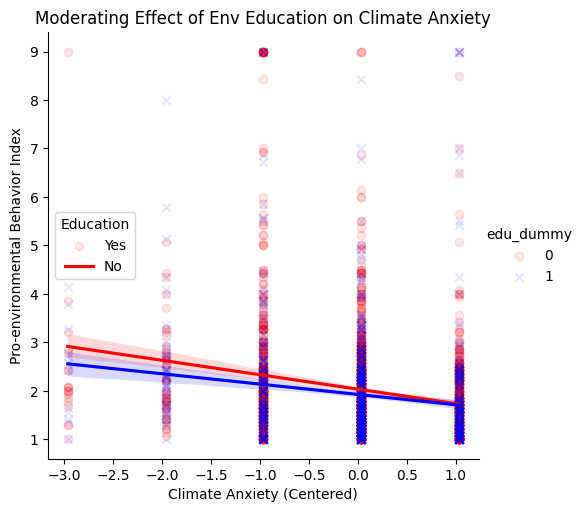

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lmplot(x='anxiety_c', y='behavior_idx', hue='edu_dummy', data=clean_df, 
           palette={1: "blue", 0: "red"}, markers=["o", "x"], scatter_kws={'alpha':0.1})

plt.title("Moderating Effect of Env Education on Climate Anxiety")
plt.xlabel("Climate Anxiety (Centered)")
plt.ylabel("Pro-environmental Behavior Index")
# 범례 수정: 1은 교육 유, 0은 교육 무
plt.legend(title="Education", labels=["Yes", "No"])
plt.show()

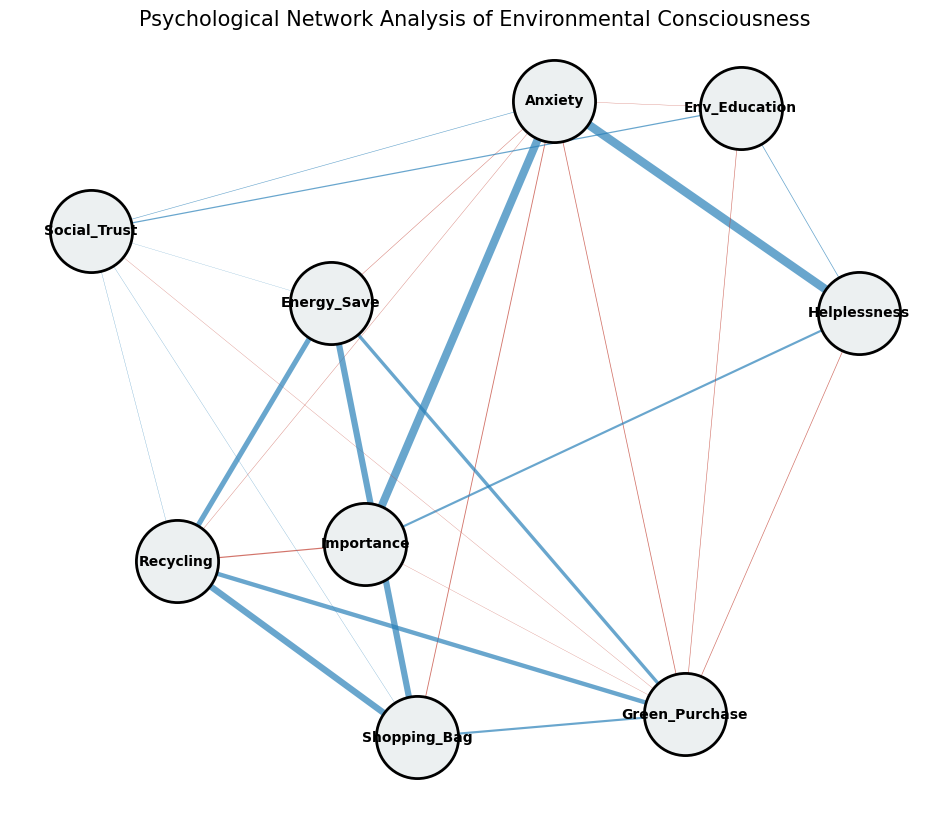

강도 중심성(Node Strength):
Anxiety: 1.0000
Green_Purchase: 1.0000
Social_Trust: 0.7500
Recycling: 0.7500
Energy_Save: 0.6250
Shopping_Bag: 0.6250
Helplessness: 0.5000
Importance: 0.5000
Env_Education: 0.5000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV

node_map = {
    'A14_1': 'Anxiety',           # 기후 불안
    'A14_3': 'Helplessness',      # 무력감
    'A11': 'Importance',          # 문제 중요성 인식
    'B6_7': 'Social_Trust',       # 사회적 신뢰
    'C9': 'Env_Education',        # 환경 교육 경험
    'B4_1': 'Energy_Save',        # 절전 실천
    'B4_6': 'Green_Purchase',     # 친환경 구매
    'B4_12': 'Shopping_Bag',      # 장바구니 사용
    'B4_14': 'Recycling'          # 분리배출
}

data = df[list(node_map.keys())].copy()
data['C9'] = data['C9'].map({1: 1, 2: 0}) 
data = data.dropna() 

scaler = StandardScaler()
X = scaler.fit_transform(data)

model = GraphicalLassoCV(cv=5)
model.fit(X)

precision = model.precision_
d = np.sqrt(np.diag(precision))
partial_corr = -precision / np.outer(d, d)
np.fill_diagonal(partial_corr, 1.0)

G = nx.Graph()
nodes = list(node_map.values())

for i, node in enumerate(nodes):
    G.add_node(node)

for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        weight = partial_corr[i, j]
        if abs(weight) > 0.01:
            G.add_edge(nodes[i], nodes[j], weight=weight)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=1.2, seed=42)

edges = G.edges(data=True)
edge_colors = ['#2980b9' if d['weight'] > 0 else '#c0392b' for u, v, d in edges]
edge_widths = [abs(d['weight']) * 15 for u, v, d in edges] 

nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='#ecf0f1', edgecolors='black', linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors, width=edge_widths, alpha=0.7)

plt.title("Psychological Network Analysis of Environmental Consciousness", fontsize=15)
plt.axis('off')
plt.show()

centrality = nx.degree_centrality(G)
print("강도 중심성(Node Strength):")
for node, val in sorted(centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"{node}: {val:.4f}")

In [ ]:

library(readxl)
library(dplyr)

read_excel("../Data/2018 국민환경의식조사/2018 국민환경 의식조사_원자료.xls",
           sheet="원자료") %>% mutate(year=2018) 
read_excel("../Data/2019 국민환경의식조사/2019 국민환경 의식조사_원자료.xls",
                   sheet="2019 국민환경의식 설문조사") %>% mutate(year=2019)
read_excel("../Data/2020 국민환경의식조사/2020 국민환경의식조사_원자료.xls",
           sheet="2020 국민환경의식조사_원자료") %>% mutate(year=2020)
read_excel("../Data/2021 국민환경의식조사/2021_국민환경의식조사_원자료.xls",
           sheet="원자료") %>% mutate(year=2021)
read_excel("../Data/2022 국민환경의식조사/2022_국민환경의식조사_원자료.xlsx",
           sheet="2022 국민환경의식 설문조사_원자료(1028)") %>% mutate(year=2022)
read_excel("../Data/2023 국민환경의식조사/2023_국민환경의식조사_원자료.xlsx",
           sheet="원자료") %>% mutate(year=2023)
dat <- read_excel("../Data/2024 국민환경의식조사/2024 국민환경의식 설문조사_원자료.xlsx",
           sheet="원자료") %>% mutate(year=2024)

dat %>% head

"불안 --> 회복 탄력성 --> 행동"
- 가설 1: 기후 불안은 환경 보호 행동에 양(+)의 영향을 미치지만, 일정 수준을 넘어서면 무력감으로 인해 음(-)의 영향(역 U자형)을 미칠 것이다.
- 가설 2: 환경 교육 경험이나 공동체 참여 의지(회복탄력성)가 높을수록, 불안이 행동으로 전환되는 확률이 높아질 것이다. (moderating effect)
- 가설 3: 위 관계는 연령(MZ세대 vs 기성세대) 및 소득 수준에 따라 유의미하게 다를 것이다. 

names(dat)
anx <- dat %>% select(A14_1:A14_8)
mod <- dat %>% select(C4_1:C4_5,C9)
act <- dat %>% select(B4_1:B4_14)



dat$pid %>% unique %>% length

